<a href="https://colab.research.google.com/github/Tecnologico-de-Monterrey-MNA/iayaa-Equipo-42/blob/main/Redneuronal_Equipo42.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Inteligencia Artificial y Aprendizaje Automático**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana 7**
###**Red Neuronal Artificial - Perceptrón Multicapa : Multilayer Perceptrón (MLP)**


**Nombres y matrículas de los integrantes del equipo:**

*  Norma de los Ángeles García López A01228278
*  Ramón Ariel Iván Muñoz Corona A01330566
*  Denisse María Ramírez Colmenero A01561497
*  Ignacio Valdés Reyes  A01793262
*  Rigoberto Vega Escudero. A01793132 


En cada sección deberás incluir todas las líneas de código necesarias para responder a cada uno de los ejercicios.

In [56]:
# Incluye aquí todos módulos, librerías y paquetes que requieras.
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import  cross_validate
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from google.colab import drive
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import power_transform
from sklearn.preprocessing import PowerTransformer

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import power_transform
from sklearn.preprocessing import FunctionTransformer

from sklearn.metrics import classification_report, make_scorer
from sklearn.compose import TransformedTargetRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import KNNImputer
import statsmodels.api as sm

#**Ejercicio-1.** 

1. En esta tarea considera únicamente la siguiente variable de salida que se concluye que es una de las
mejores en el artículo antes citado: ‘Lifetime People who have liked a Page and engaged with a
post'. Renombra dicha variable como “LPE” . Como variables de entrada selecciona las 7 variables
que indican los autores en la Tabla 3 del artículo citado. 


In [57]:
drive.mount('/content/drive')
#mypath = "/content/SouthGermanCredit.asc"
mypath = '/content/drive/MyDrive/Colab Notebooks/Inteligencia Artificial/Actividad 8/dataset_Facebook.csv'
data = pd.read_csv(mypath, sep=";")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
data.dtypes

Page total likes                                                         int64
Type                                                                    object
Category                                                                 int64
Post Month                                                               int64
Post Weekday                                                             int64
Post Hour                                                                int64
Paid                                                                   float64
Lifetime Post Total Reach                                                int64
Lifetime Post Total Impressions                                          int64
Lifetime Engaged Users                                                   int64
Lifetime Post Consumers                                                  int64
Lifetime Post Consumptions                                               int64
Lifetime Post Impressions by people who have liked y

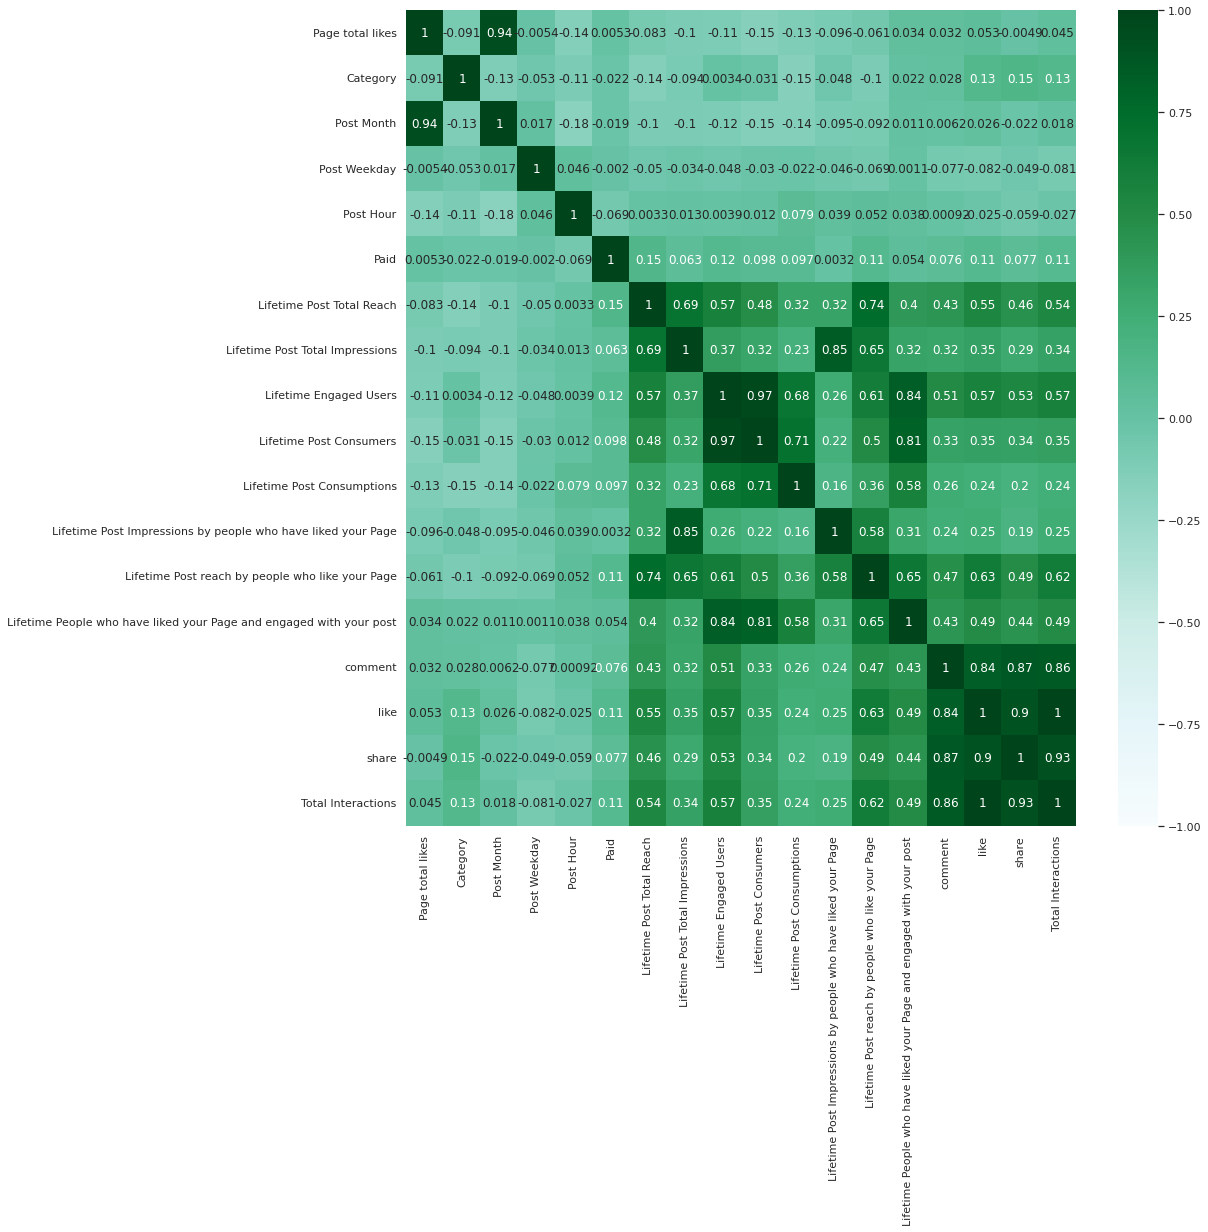

In [59]:
data.corr()
corrs = data.corr()
sns.set(rc = {'figure.figsize':(15,15)})
sns.heatmap(corrs, vmin = -1, vmax = 1, cmap = "BuGn", annot= True)


Podemos observar que las variables de entrada contra LPE no estan muy relacionadas entre ellas, esto puede ser un factor para los resultados mas adelante.

In [60]:
data = data.rename(columns = {'Lifetime People who have liked your Page and engaged with your post':'LPE'})
print(data.shape)
data.columns

(500, 19)


Index(['Page total likes', 'Type', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Paid', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page', 'LPE', 'comment',
       'like', 'share', 'Total Interactions'],
      dtype='object')

In [61]:
entrada = ['Category', 'Page total likes', 'Type', 'Post Month', 'Post Hour', 'Post Weekday', 'Paid']
salida = ['LPE']

In [62]:
lbe = LabelEncoder()
data["Type"]= lbe.fit_transform(data["Type"])
data["Type"].unique()

array([1, 2, 0, 3])

In [63]:
data["Type"]

0      1
1      2
2      1
3      1
4      1
      ..
495    1
496    1
497    1
498    1
499    1
Name: Type, Length: 500, dtype: int64

In [64]:
data[entrada].isna().any()

Category            False
Page total likes    False
Type                False
Post Month          False
Post Hour           False
Post Weekday        False
Paid                 True
dtype: bool

In [65]:
X , y =   data[entrada], data[salida] 

In [66]:
X.head()

,Category,Page total likes,Type,Post Month,Post Hour,Post Weekday,Paid
0,2,139441,1,12,3,4,0.0
1,2,139441,2,12,10,3,0.0
2,3,139441,1,12,3,3,0.0
3,2,139441,1,12,10,2,1.0
4,2,139441,1,12,3,2,0.0


#**Ejercicio-2.**

2. Realiza una partición de los datos con 100 datos de Prueba y el resto para entrenamiento y
validación. 

In [67]:
X.shape

(500, 7)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [69]:
X_test.shape

(100, 7)

#**Ejercicio-3.**

3. Definirás tus propias funciones de errores para este problema de regresión. Los errores que
utilizarás son la raíz cuadrada del error cuadrático medio RMSE, el error absoluto medio MAE y el
error porcentual absoluto medio MAPE. 


In [70]:
def mi_RMSE(y_true, predictions):
  y_true, predictions = np.array(y_true), np.array(predictions)
  diff=np.subtract(y_true,predictions)
  square=np.square(diff)
  MSE=square.mean()
  RMSE=np.sqrt(MSE)
  return RMSE

def mi_MAE(y_true, predictions):
    y_true, predictions = np.array(y_true), np.array(predictions)
    return np.mean(np.abs(y_true - predictions))

def mi_MAPE(y_true, predictions): 
    y_true, predictions = np.array(y_true), np.array(predictions)
    return np.mean(np.abs((y_true - predictions) / y_true))

Me_RMSE = make_scorer(mi_RMSE, greater_is_better= False)
Me_MAE = make_scorer(mi_MAE, greater_is_better= False)
Me_MAPE = make_scorer(mi_MAPE, greater_is_better= False)

mismetricas = {"RMSE":Me_RMSE,"MAE":Me_MAE,"MAPE":Me_MAPE}

#**Ejercicio-4.**

4. En la página de la UCI, así como en el artículo de los autores previamente citado encuentras información en relación al significado de cada variable. Haz una análisis de tus datos y lleva a cabo las transformaciones que consideres adecuadas tanto en los datos de entrada, como en las de salida.
Utiliza un Pipeline para evitar el filtrado de información. 


In [71]:
X.columns

Index(['Category', 'Page total likes', 'Type', 'Post Month', 'Post Hour',
       'Post Weekday', 'Paid'],
      dtype='object')

In [72]:
#Definicion de variables
# categorical
categorica = ['Category', 'Type']

# discretized quantitative
ordinal = ['Post Month', 'Post Weekday', 'Post Hour']
#quantitative
numerica = ['Page total likes']
# Binaria
binaria = ['Paid']

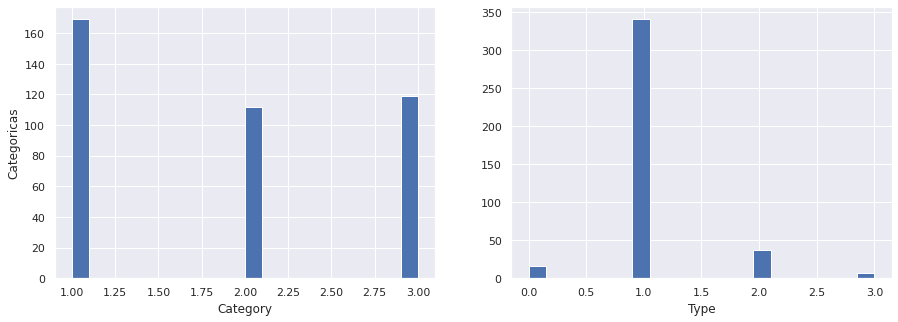

In [73]:
#Categorica
categorica
sns.set(rc={'figure.figsize':(15,5)})
fig, axes = plt.subplots(1, 2)   
for k in range(0,2):  
  plt.subplot(1,2,k+1) 

  Transf0 = X_train[categorica].iloc[:,k].to_numpy().reshape(-1, 1)  #  En esta línea se debe asignar a Transf0 los valores de cada variable "k" sin transformar.
  plt.hist(Transf0, bins=20) 
  plt.xlabel(categorica[k])
  if k==0:
    plt.ylabel('Categoricas')

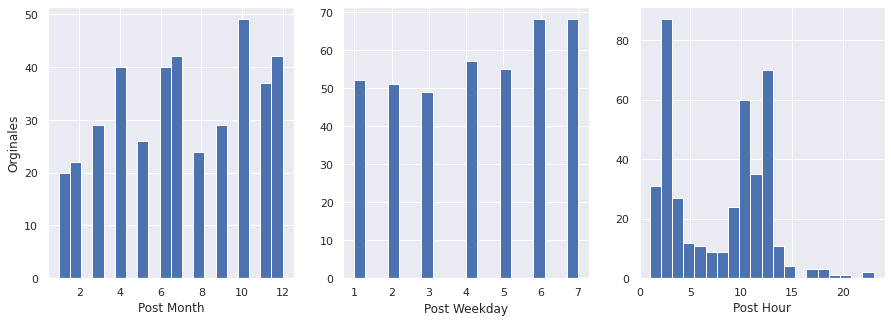

In [74]:
k=0
fig, axes = plt.subplots(1, 3)   
for k in range(0,3):  
  plt.subplot(1,3,k+1) 

  Transf0 = X_train[ordinal].iloc[:,k].to_numpy().reshape(-1, 1)  #  En esta línea se debe asignar a Transf0 los valores de cada variable "k" sin transformar.
  plt.hist(Transf0, bins=20) 
  plt.xlabel(ordinal[k])
  if k==0:
    plt.ylabel('Orginales')
  


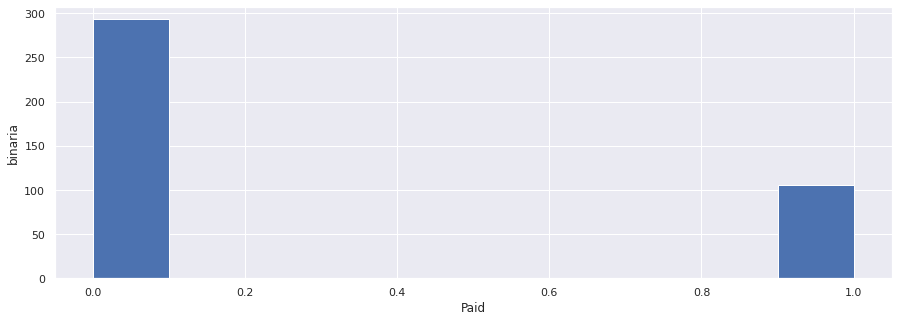

In [75]:
k=0
fig, axes = plt.subplots(1, 1)   
for k in range(0,1):  
  plt.subplot(1,1,k+1) 

  Transf0 = X_train[binaria].iloc[:,k].to_numpy().reshape(-1, 1)  #  En esta línea se debe asignar a Transf0 los valores de cada variable "k" sin transformar.
  plt.hist(Transf0) 
  plt.xlabel(binaria[k])
  if k==0:
    plt.ylabel('binaria')

In [76]:
X_train_nor = X_train[numerica].copy()
scaler = MinMaxScaler(feature_range=(1,2))
scaler.fit(X_train_nor)
X_Train_NOM = scaler.transform(X_train_nor)
X_Train_NOM = pd.DataFrame(X_Train_NOM,dtype = 'float')
X_Train_NOM

,0
0,1.953419
1,1.651409
2,1.973343
3,1.165986
4,2.000000
...,...
395,1.717690
396,1.900777
397,1.951800
398,1.981264


/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

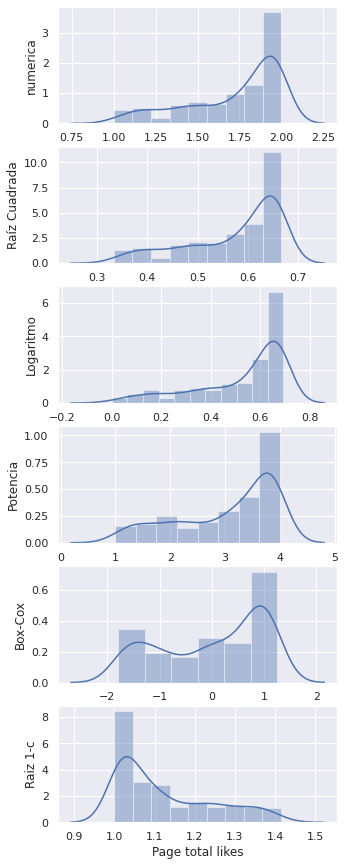

In [77]:
sns.set(rc={'figure.figsize':(5,15)})
#Numerica
k=0
fig, axes = plt.subplots(6, 1)   
for k in range(0,1):  
  plt.subplot(6,1,k+1) 

  Transf0 = X_Train_NOM.iloc[:,k].to_numpy().reshape(-1, 1)  
  sns.distplot(Transf0) 
  plt.xlabel(numerica[k])
  if k==0:
    plt.ylabel('numerica')
  
  plt.subplot(6,1,k+2)    
  Transf1 = Transf0**1/3       
  sns.distplot(Transf1)                      
  if k==0:
    plt.ylabel('Raíz Cuadrada')

  plt.subplot(6,1,k+3)    
  Transf2 = np.log(Transf0)       
  sns.distplot(Transf2)                      
  plt.xlabel(numerica[k])
  if k==0:
    plt.ylabel('Logaritmo')

  plt.subplot(6,1,k+4)    
  Transf3 = Transf0**2    
  sns.distplot(Transf3)   
  plt.xlabel(numerica[k])
  if k==0:
    plt.ylabel('Potencia')
  
  plt.subplot(6,1,k+5)
  Transf4 = power_transform(X_Train_NOM.iloc[:,k].to_numpy().reshape(-1, 1), method='box-cox')        
  sns.distplot(Transf4)                  
  plt.xlabel(numerica[k])
  if k==0:
   plt.ylabel('Box-Cox')

  plt.subplot(6,1,k+6)
  Transf4 = np.sqrt((X_Train_NOM.max()+1)-X_Train_NOM)       
  sns.distplot(Transf4)                  
  plt.xlabel(numerica[k])
  if k==0:
   plt.ylabel('Raiz 1-c')

Aqui utilizar el sesgo al reves se pudo agrupar mejor los datos dentro de la normalidad, esperando que esto nos ayude en el entrenamiento de los modelos.

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

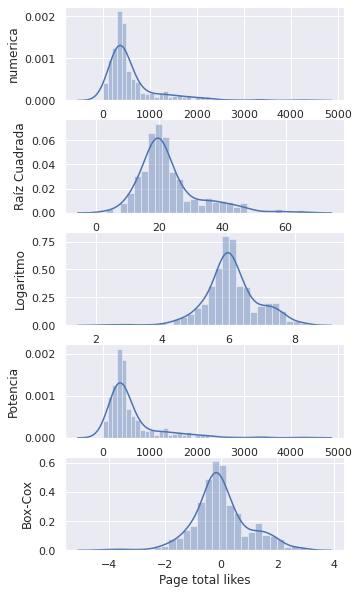

In [78]:
sns.set(rc={'figure.figsize':(5,10)})
#Numerica
k=0
fig, axes = plt.subplots(5, 1)   
for k in range(0,1):  
  plt.subplot(5,1,k+1) 

  Transf0 = y_train.iloc[:,k].to_numpy().reshape(-1, 1)  
  sns.distplot(Transf0) 
  plt.xlabel(numerica[k])
  if k==0:
    plt.ylabel('numerica')
  
  plt.subplot(5,1,k+2)    
  Transf1 = np.sqrt(Transf0)       
  sns.distplot(Transf1)                      
  if k==0:
    plt.ylabel('Raíz Cuadrada')

  plt.subplot(5,1,k+3)    
  Transf2 = np.log(Transf0)       
  sns.distplot(Transf2)                      
  plt.xlabel(numerica[k])
  if k==0:
    plt.ylabel('Logaritmo')

  plt.subplot(5,1,k+4)    
  Transf3 = np.exp(Transf2)
  sns.distplot(Transf3)      
  plt.xlabel(numerica[k])
  if k==0:
    plt.ylabel('Potencia')
  
  plt.subplot(5,1,k+5)
  Transf4 = power_transform(y_train.iloc[:,k].to_numpy().reshape(-1, 1), method='box-cox')        
  sns.distplot(Transf4)                  
  plt.xlabel(numerica[k])
  if k==0:
   plt.ylabel('Box-Cox')

In [79]:
def SqrtMax (X):
  X_=X.copy()
  X_=np.sqrt((X_.max()+1)-X_)
  return(X_)

In [80]:
# Transformación para disminuir sesgo positivo:
def y_Transform(Y):
  #print("Transf(y)\n")  # Por si deseas ver cuándo se manda llamar esta función.
  Y_ = Y.copy() 
  Y_ = np.log(Y_)
  return Y_

# Inversa de la variable de salida que se usará para las predicciones:
def y_inverseTransform(Y):
  #print("invTransf(y)\n")
  Y_ = Y.copy() 
  Y_ = np.exp(Y_)
  return Y_

In [81]:
#Pipelines                                                     
num_prepro_pipeline = Pipeline(steps = [('impMedian', SimpleImputer(strategy='median')),  
                                        ('scalar', MinMaxScaler(feature_range=(1,2))) ,
                                         ('SqrtMax', FunctionTransformer(SqrtMax))])  
num_pipeline_nombres = numerica


#######################################################################################################   
num_prepro_pipelineST = Pipeline(steps = [('imputet', SimpleImputer(strategy='median')),  
                                        ('scalar', MinMaxScaler(feature_range=(1,2))) ,
                                         ])  
num_pipeline_nombresST = numerica
#######################################################################################################  
Cat_prepro_pipeline = Pipeline(steps = [('impModa', SimpleImputer(strategy='most_frequent')),
                                        ('OneHotE', OneHotEncoder(handle_unknown='ignore'))])
 
Cat_pipeline_nombres = categorica

#######################################################################################################   
Ord_prepro_pipeline = Pipeline(steps = [('impModa', SimpleImputer(strategy='most_frequent')),
                                        ('OneHotE', OneHotEncoder(handle_unknown='ignore'))
                                                                                ])
   
Ord_pipeline_nombres = ordinal
#######################################################################################################   
Bin_prepro_pipeline = Pipeline(steps = [('impModa', SimpleImputer(strategy='most_frequent')),
                                       
                                       ]) 
Bin_pipeline_nombres = binaria

#######################################################################################################   
sal_prepro_pipeline = Pipeline(steps = [('impMedian', SimpleImputer(strategy='median')),  
                                        ('scalar', MinMaxScaler(feature_range=(1,2)))  ])
sal_prepro_nombres = salida

#######################################################################################################   
columnasTransformer = ColumnTransformer(transformers = [('numerical', num_prepro_pipeline, num_pipeline_nombres),
                                        ('categoricaimp1', Cat_prepro_pipeline, Cat_pipeline_nombres),
                                         ('ordinalimp', Ord_prepro_pipeline, Ord_pipeline_nombres),
                                         ('binarialimp', Bin_prepro_pipeline, Bin_pipeline_nombres),
                                         ],  remainder='passthrough')
#######################################################################################################  
columnasTransformerST = ColumnTransformer(transformers = [('numericalST', num_prepro_pipelineST, num_pipeline_nombresST),
                                        ('categoricaimp1', Cat_prepro_pipeline, Cat_pipeline_nombres),
                                         ('ordinalimp', Ord_prepro_pipeline, Ord_pipeline_nombres),
                                         ('binarialimp', Bin_prepro_pipeline, Bin_pipeline_nombres),
                                         ])
#######################################################################################################  
columnasTransformerSalida = ColumnTransformer(transformers = [('numerical', sal_prepro_pipeline, sal_prepro_nombres),
                                                                                ])

#**Ejercicio-5.**

5. Utiliza la función Dummy para modelos de regresión de scikit-learn con el conjunto que tienes de datos de entrenamiento y validación. Para ello particiónalos en 100 para validación y 300 para entrenamiento. Encuentra los errores RMSE, MAE y MAPE para los conjuntos de entrenamiento y validación. Estos serán tus errores máximos que deberás tomar como referencia en el resto de la actividad. Consulta su documentación correspondiente:
https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html 

In [82]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_train, y_train, train_size=0.75, random_state=42)
dummy_regr = DummyRegressor(strategy="median")
pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',dummy_regr)])

modelo = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,     # transformación para ajuste del sesgo.
                                    inverse_func=y_inverseTransform    # Para regresar los valores "y" en la escala original.
                                    )

modelo.fit(X_train_2, y_train_2) 

y_test_hat = modelo.predict(X_test_2)
y_train_hat = modelo.predict(X_train_2)

# pipeline.fit(X_train_2, y_train_2)
# y_test_hat = pipeline.predict(X_test_2)
# y_train_hat = pipeline.predict(X_train_2)

print("Validacion\n")
print("RMSE with dummy Regression: {:.2f}".format(mi_RMSE(y_test_2, y_test_hat)))
print("MAE with dummy Regression: {:.2f}".format(mi_MAE(y_test_2,y_test_hat)))
print("MAPE with dummy Regression: {:.2f}".format(mi_MAPE(y_test_2,y_test_hat)))
print("\nEntrenamiento\n")
print("RMSE with dummy Regression: {:.2f}".format(mi_RMSE(y_train_2, y_train_hat)))
print("MAE with dummy Regression: {:.2f}".format(mi_MAE(y_train_2,y_train_hat)))
print("MAPE with dummy Regression: {:.2f}".format(mi_MAPE(y_train_2,y_train_hat)))

Validacion

RMSE with dummy Regression: 414.26
MAE with dummy Regression: 253.51
MAPE with dummy Regression: 0.64

Entrenamiento

RMSE with dummy Regression: 683.81
MAE with dummy Regression: 371.12
MAPE with dummy Regression: 0.95


#**Ejercicio-6.**

6. Usando los modelos de regresión lineal múltiple, el bosque aleatorio y el perceptrón multicapa con sus valores predeterminados, lleva a cabo su entrenamiento con repeticiones de validación cruzada (RepeatedKFold) y desplegando los errores RMSE, MAE y MAPE. Recuerda evitar el filtrado de
información usando los datos que obtuviste en el ejercicio 2. Incluye las conclusiones sobre el mejor modelo encontrado en esta primera aproximación. En particular ¿hay alguno sobreentrenado o subentrenado? NOTA: Recuerda que puedes aumentar en dado caso el número máximo de iteraciones para que todos los modelos converjan. 


In [83]:
def get_models():
  modelos = list()
  nombres = list()

  # LR - Regresión Logística:
  modelos.append(LinearRegression())
  nombres.append('LR')

  # RFC - andom Forest / Bosque Aleatorio:
  modelos.append(RandomForestRegressor())
  nombres.append('RFC')
  
  # MLP - MLPRegressor / Perceptrón Multicapa:  
  modelos.append(MLPRegressor(max_iter=100000))
  nombres.append('MLP')
  
  
  return modelos, nombres

In [84]:
modelos, nombres = get_models()  # cargamos los modelos a comparar
resultados = list()   

for i in range(len(modelos)):
  
  pipeline = Pipeline(steps=[('ct1',columnasTransformer),('m',modelos[i])])
  modelo = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,     # transformación para ajuste del sesgo.
                                    inverse_func=y_inverseTransform    # Para regresar los valores "y" en la escala original.
                                    )
  cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=7)
  
  scores = cross_validate(modelo, X_train, y_train, scoring=mismetricas, cv=cv, return_train_score=True)


  resultados.append(scores)
  print('>> %s: \n' % (nombres[i]))
  print("Entrenamiento\n")
  print('mean RMSE: %.3f (%.4f)\nmean MAE: %.3f (%.4f)\nmean MAPE: %.3f (%.4f)\n' % (np.mean(resultados[i]['train_RMSE']),
                                                                                         np.std(resultados[i]['train_RMSE']),
                                                                                         np.mean(resultados[i]['train_MAE']),
                                                                                         np.std(resultados[i]['train_MAE']),
                                                                                         np.mean(resultados[i]['train_MAPE']),
                                                                                         np.std(resultados[i]['train_MAPE']),  
                                                                                                 ))
  print("Prueba\n")  
  print('mean RMSE: %.3f (%.4f)\nmean MAE: %.3f (%.4f)\nmean MAPE: %.3f (%.4f)\n' % (np.mean(resultados[i]['test_RMSE']),
                                                                                         np.std(resultados[i]['test_RMSE']),
                                                                                         np.mean(resultados[i]['test_MAE']),
                                                                                         np.std(resultados[i]['test_MAE']),
                                                                                         np.mean(resultados[i]['test_MAPE']),
                                                                                         np.std(resultados[i]['test_MAPE']),  
                                                                                                 ))


>> LR: 

Entrenamiento

mean RMSE: -474.984 (17.2839)
mean MAE: -259.261 (9.5431)
mean MAPE: -0.573 (0.0417)

Prueba

mean RMSE: -523.409 (92.9352)
mean MAE: -303.966 (34.9868)
mean MAPE: -0.788 (0.3214)

>> RFC: 

Entrenamiento

mean RMSE: -255.199 (13.5891)
mean MAE: -122.744 (5.3731)
mean MAPE: -0.197 (0.0099)

Prueba

mean RMSE: -499.533 (94.8976)
mean MAE: -288.630 (36.3150)
mean MAPE: -0.761 (0.3104)

>> MLP: 

Entrenamiento

mean RMSE: -200.897 (23.4715)
mean MAE: -98.077 (12.1247)
mean MAPE: -0.171 (0.0199)

Prueba

mean RMSE: -604.491 (97.0736)
mean MAE: -370.213 (44.6419)
mean MAPE: -1.019 (0.4588)



**¿hay alguno sobreentrenado o subentrenado?**

Al final del día la métrica de MAPE puede ser nuestro mejor indicador para saber que tan subentrenado o sobreentrenado puede o no estar un modelo, ya que dicha métrica nos ayuda a comparar el error a través de la información aun teniendo diferentes escalas. Revisando los resultados entre los 3 podemos notar que tenemos un error del 80% en promedio, parece subentrenado ya que buscamos que el error sea de lo más mínimo, y aquí no es el caso. Entonces podemos concluir que tenemos un sesgo bastante alto entre los errores.

#**Ejercicio-7.**

7. Obtener los diagramas de caja y bigote para los errores MAPE de los conjuntos de validación obtenidos. En particular compara estos primeros resultados de MAPE con el mejor resultado que encuentran los autores del artículo citado al inicio. Incluye tus conclusiones. 


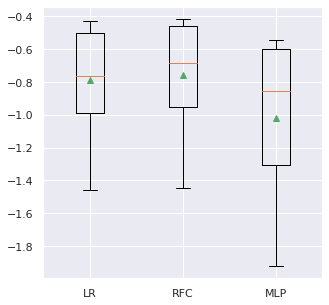

In [85]:
sns.set(rc={'figure.figsize':(5,5)})



bpMAPE = list()
for i in range(len(resultados)):
  rr = resultados[i]['test_MAPE']
  bpMAPE.append(rr)

plt.boxplot(bpMAPE, labels=nombres, showmeans=True)
plt.show()



plt.show()

Conclusiones.

Al revisar el articulo menciona un MAPE del 27%, es increíble ver ese número ya que nosotros obtenemos un error de tal valor y tan bajo. Solo es un fuerte indicador que necesitamos encontrar mejores hyperparametros para nuestros modelos, ya que estamos en 80% de error, muy alejado del conseguido por los autores del artículo.

#**Ejercicio-8.**

8. Usando una búsqueda de malla con validación cruzada (GridSearchCV), busca los mejores hiperparámetros para el modelo MLP. Al menos deberás realizar la búsqueda en los hiperparámetros “hidden_layer_sizes”, “alpha” y “learning_rate_init”. Además aplica la validación cruzada con repeticiones (RepeatedKFold). Muestra los mejores hiperparámetros encontrados. 

In [103]:
modeloMLP = MLPRegressor(max_iter=100000)


pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modeloMLP)])
modelo = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,     # transformación para ajuste del sesgo.
                                    inverse_func=y_inverseTransform    # Para regresar los valores "y" en la escala original.
                                    )
# dicc_grid = [{'regressor__modelo__hidden_layer_sizes':[(100,),(10,10,10),(10,10),(20,20),(30,30)],
#              'regressor__modelo__alpha':[.001,0.000001,],
#              'regressor__modelo__learning_rate_init':[0.0001,0.000001]
#                                        }]

# dicc_grid = [{'regressor__modelo__hidden_layer_sizes':[(80,)],
#              'regressor__modelo__alpha':[0.000001,],
#              'regressor__modelo__learning_rate_init':[0.000001]
#                                        }]
#Se deja los mejores parametros encontrados para evitar el tiempo de Grid de alrededor de 1 hora y 45 minutos
dicc_grid = [{'regressor__modelo__hidden_layer_sizes':[(10,10,10)],
             'regressor__modelo__alpha':[0.001],
             'regressor__modelo__learning_rate_init':[0.000001]
                                       }]
                                       
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=7)

grid = GridSearchCV(estimator=modelo, 
                    param_grid=dicc_grid, 
                    cv=cv, 
                    scoring=Me_MAPE,
                    n_jobs=-1)

grid.fit(X_train, np.ravel(y_train))


print('Mejor valor de MAPE obtenido con la mejor combinación:', grid.best_score_)
print('Mejor combinación de valores encontrados de los hiperparámetros:', grid.best_params_)
print('Métrica utilizada:', grid.scoring)


Mejor valor de MAPE obtenido con la mejor combinación: -0.965038394188766
Mejor combinación de valores encontrados de los hiperparámetros: {'regressor__modelo__alpha': 0.001, 'regressor__modelo__hidden_layer_sizes': (10, 10, 10), 'regressor__modelo__learning_rate_init': 1e-06}
Métrica utilizada: make_scorer(mi_MAPE, greater_is_better=False)


#**Ejercicio-9.**

9. Con los mejores valores de los hiperparámetros encontrados realiza un análisis de la importancia de los factores. Muestra un diagrama de barras de los resultados e incluye tus conclusiones. 


Feature: 0, Score: -0.00001
Feature: 1, Score: -0.00000
Feature: 2, Score: -0.00002
Feature: 3, Score: -0.00003
Feature: 4, Score: -0.00000
Feature: 5, Score: -0.00001
Feature: 6, Score: 0.00002


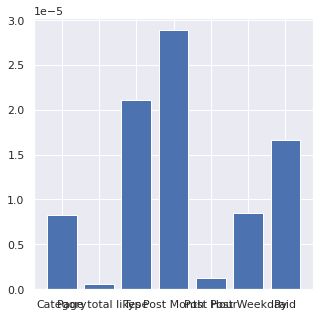

In [104]:
modelo_MLP = MLPRegressor(hidden_layer_sizes=grid.best_params_.get('regressor__modelo__hidden_layer_sizes'), 
                            max_iter=100000, 
                            alpha=grid.best_params_.get('regressor__modelo__alpha'),
                            learning_rate_init=grid.best_params_.get('regressor__modelo__learning_rate_init')) 

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_MLP)])
modelo_MLP_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,    
                                    inverse_func=y_inverseTransform    
                                    ) 

modelo_MLP_C.fit(X_train, y_train)

importanceMLP = permutation_importance(modelo_MLP_C, X_train, y_train, n_repeats=10, scoring=Me_MAPE)


for i,v in enumerate(importanceMLP['importances_mean']):
	print('Feature: %0d, Score: %.5f' % (i,v))
 
plt.bar(X.columns, abs(importanceMLP['importances_mean']))
plt.show()

In [105]:
#Analisis de rendimiento del modelo MLP
modelo_MLP = MLPRegressor(hidden_layer_sizes=grid.best_params_.get('regressor__modelo__hidden_layer_sizes'), 
                            max_iter=100000, 
                            alpha=grid.best_params_.get('regressor__modelo__alpha'),
                            learning_rate_init=grid.best_params_.get('regressor__modelo__learning_rate_init')) 

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_MLP)])
modelo_MLP_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,    
                                    inverse_func=y_inverseTransform    
                                    ) 
modelo_MLP_C.fit(X_train, y_train) 
y_test_hat = modelo_MLP_C.predict(X_test)



LPE    4376
dtype: int64
1360.2292446734657
LPE    897.704436
dtype: float64


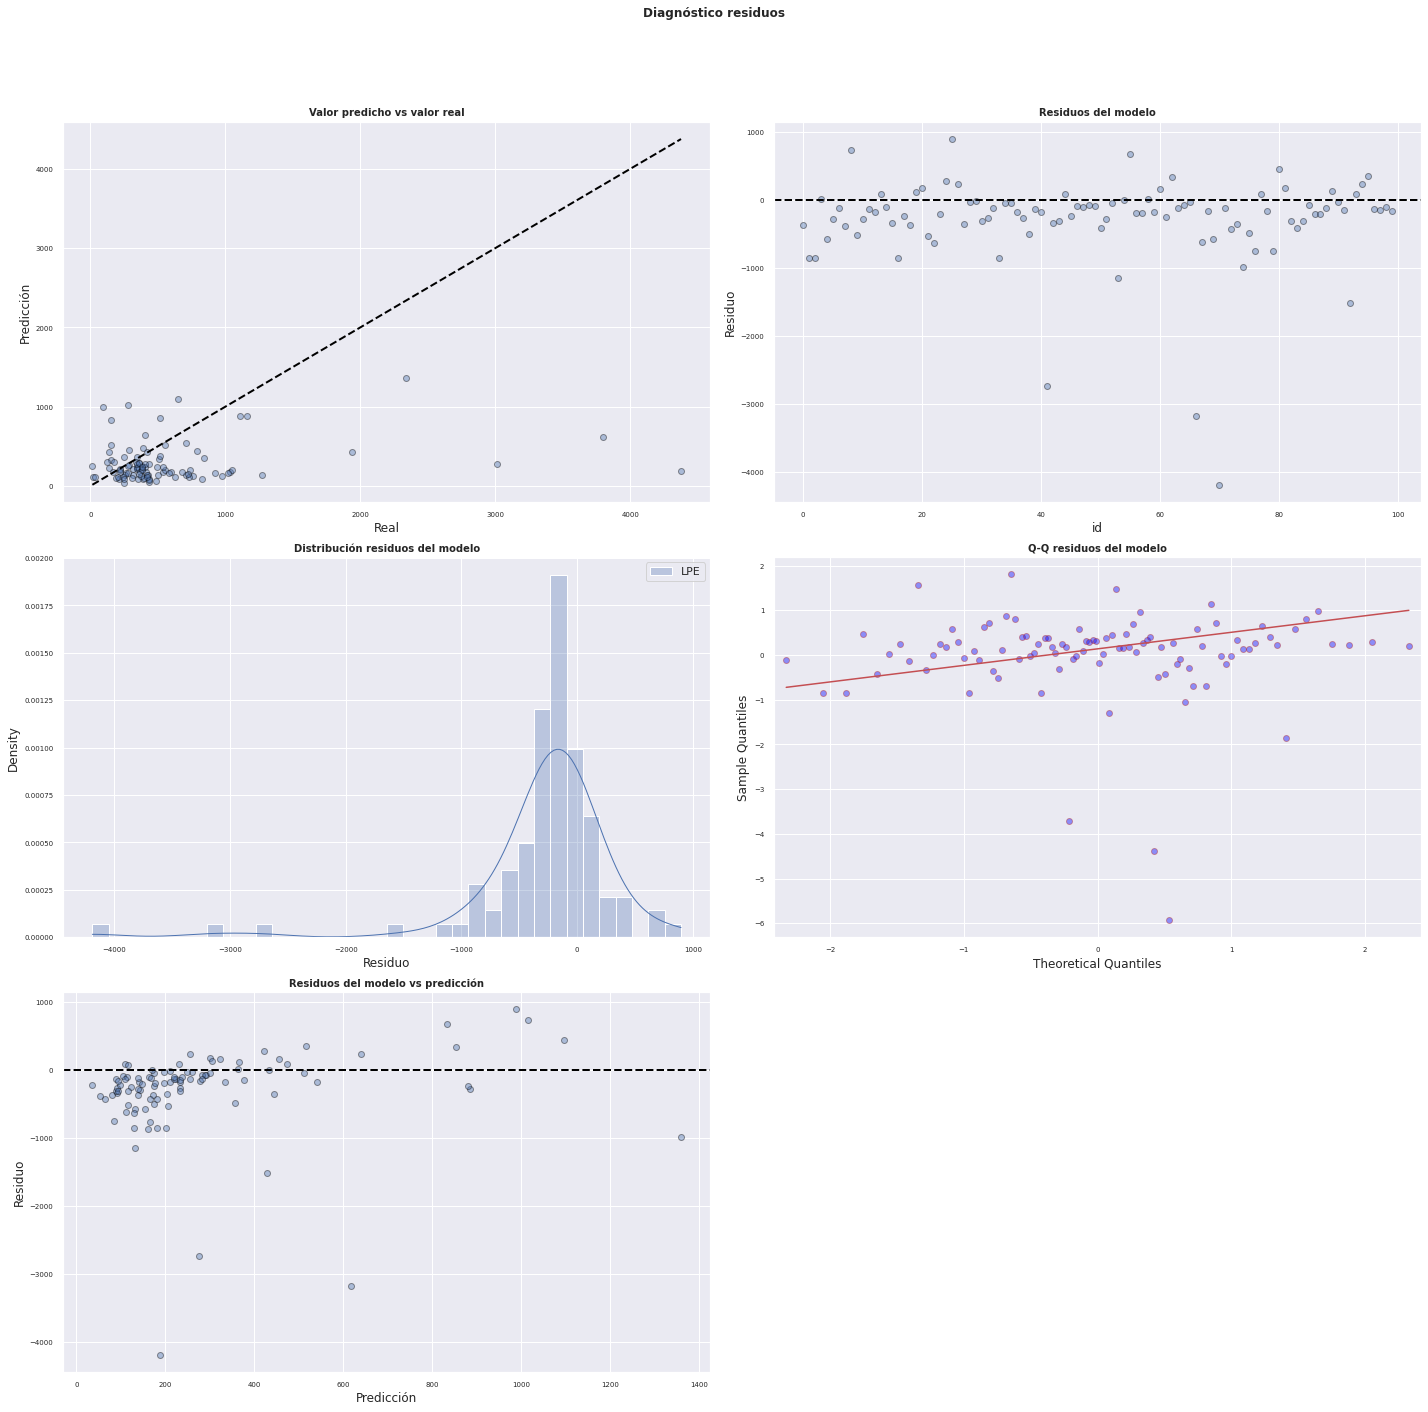

In [106]:
residuos_train   = y_test_hat - y_test
print(y_test.max())
print(y_test_hat.max())
print(residuos_train.max())


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))

axes[0, 0].scatter(y_test, y_test_hat, edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'k--', color = 'black', lw=2)
axes[0, 0].set_title('Valor predicho vs valor real', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Predicción')
axes[0, 0].tick_params(labelsize = 7)

axes[0, 1].scatter(list(range(len(y_test))), residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 1].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[0, 1].set_title('Residuos del modelo', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].tick_params(labelsize = 7)

sns.histplot(
    data    = residuos_train,
    stat    = "density",
    kde     = True,
    line_kws= {'linewidth': 1},
    color   = "firebrick",
    alpha   = 0.3,
    ax      = axes[1, 0]
)

axes[1, 0].set_title('Distribución residuos del modelo', fontsize = 10,
                     fontweight = "bold")
axes[1, 0].set_xlabel("Residuo")
axes[1, 0].tick_params(labelsize = 7)


sm.qqplot(
    residuos_train,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    color = 'firebrick',
    alpha = 0.4,
    lw    = 2
)
axes[1, 1].set_title('Q-Q residuos del modelo', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

axes[2, 0].scatter(y_test_hat, residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[2, 0].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[2, 0].set_title('Residuos del modelo vs predicción', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Predicción')
axes[2, 0].set_ylabel('Residuo')
axes[2, 0].tick_params(labelsize = 7)

# Se eliminan los axes vacíos
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Diagnóstico residuos', fontsize = 12, fontweight = "bold");

Conclusiones.

Al evaluar el feature importance del modelo MLRregressor podemos notar que el feature importance, le da mucho peso al Type y a Page total likes. Diciendo que estos valores aportan gran parte de los pesos de las predicciones dadas por el modelo de regresión de la red neuronal, pero el error del valor de MAPE sigue siendo de un valor bastante elevado, provocando que necesitamos revisar como ajustar la data para poder dar una conclusión al por que el tamaño de este error.

#**Ejercicio-10.**

10. Repite el ejercicio 8 y 9 para el modelo de bosque aleatorio para buscar sus mejores hiperparámetros (realiza la búsqueda con aquellos hiperparámetros que consideres más adecuados) y usando el conjunto de Prueba. Y realiza igualmente el análisis de importancia de factores con este modelo con un diagrama de barras. 


In [108]:
modeloRFC = RandomForestRegressor()


pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modeloRFC)])
modelo = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,     
                                    inverse_func=y_inverseTransform    
                                    )
# dicc_grid = [{'regressor__modelo__max_depth':[2,6,10,12],
#              'regressor__modelo__ccp_alpha':[0.001,0.0001,0.000001,],
#              'regressor__modelo__n_estimators':[200, 400, 600],
#              'regressor__modelo__min_samples_split':[2,4,8,10,12],
#                                                      }]
#mejores modelos para evitar los 30 minutos de grid
dicc_grid = [{'regressor__modelo__max_depth':[6],
             'regressor__modelo__ccp_alpha':[0.001],
             'regressor__modelo__n_estimators':[600],
             'regressor__modelo__min_samples_split':[12],
                                                     }]
                                                     
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=7)

grid = GridSearchCV(estimator=modelo, 
                    param_grid=dicc_grid, 
                    cv=cv, 
                    scoring=Me_MAPE)

grid.fit(X_train, np.ravel(y_train))


print('Mejor valor de MAPE obtenido con la mejor combinación:', grid.best_score_)
print('Mejor combinación de valores encontrados de los hiperparámetros:', grid.best_params_)
print('Métrica utilizada:', grid.scoring)


Mejor valor de MAPE obtenido con la mejor combinación: -0.7030366632940471
Mejor combinación de valores encontrados de los hiperparámetros: {'regressor__modelo__ccp_alpha': 0.001, 'regressor__modelo__max_depth': 6, 'regressor__modelo__min_samples_split': 12, 'regressor__modelo__n_estimators': 600}
Métrica utilizada: make_scorer(mi_MAPE, greater_is_better=False)


Feature: 0, Score: -0.04502
Feature: 1, Score: 0.00737
Feature: 2, Score: -0.06860
Feature: 3, Score: -0.00325
Feature: 4, Score: 0.00959
Feature: 5, Score: -0.04091
Feature: 6, Score: -0.00146


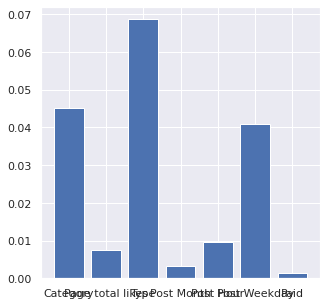

In [109]:
#Modelo con Valores de entrenamiento
modelo_RFC = RandomForestRegressor(max_depth=grid.best_params_.get('regressor__modelo__max_depth'), 
                            ccp_alpha=grid.best_params_.get('regressor__modelo__ccp_alpha'), 
                            n_estimators=grid.best_params_.get('regressor__modelo__n_estimators'),
                            min_samples_split=grid.best_params_.get('regressor__modelo__min_samples_split')) 

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_RFC)])
modelo_RFC_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,    
                                    inverse_func=y_inverseTransform    
                                    ) 

modelo_RFC_C.fit(X_train, np.ravel(y_train))

importanceRFC = permutation_importance(modelo_RFC_C, X_train, y_train, n_repeats=10,scoring=Me_MAPE)


for i,v in enumerate(importanceRFC['importances_mean']):
	print('Feature: %0d, Score: %.5f' % (i,v))
 
plt.bar(X.columns, abs(importanceRFC['importances_mean']))
plt.show()

Feature: 0, Score: -0.00176
Feature: 1, Score: -0.03350
Feature: 2, Score: -0.03733
Feature: 3, Score: -0.02181
Feature: 4, Score: -0.01814
Feature: 5, Score: -0.01388
Feature: 6, Score: -0.00037


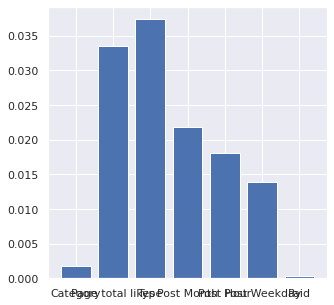

In [110]:
#Modelo con Valores de Prueba
modelo_RFC = RandomForestRegressor(max_depth=grid.best_params_.get('regressor__modelo__max_depth'), 
                            ccp_alpha=grid.best_params_.get('regressor__modelo__ccp_alpha'), 
                            n_estimators=grid.best_params_.get('regressor__modelo__n_estimators'),
                            min_samples_split=grid.best_params_.get('regressor__modelo__min_samples_split')) 

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_RFC)])
modelo_RFC_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,    
                                    inverse_func=y_inverseTransform    
                                    ) 

modelo_RFC_C.fit(X_test, np.ravel(y_test))

importanceRFC = permutation_importance(modelo_RFC_C, X_test, y_test, n_repeats=10,scoring=Me_MAPE)


for i,v in enumerate(importanceRFC['importances_mean']):
	print('Feature: %0d, Score: %.5f' % (i,v))
 
plt.bar(X.columns, abs(importanceRFC['importances_mean']))
plt.show()

LPE    4376
dtype: int64
2215.301050720186
LPE    1977.637064
dtype: float64


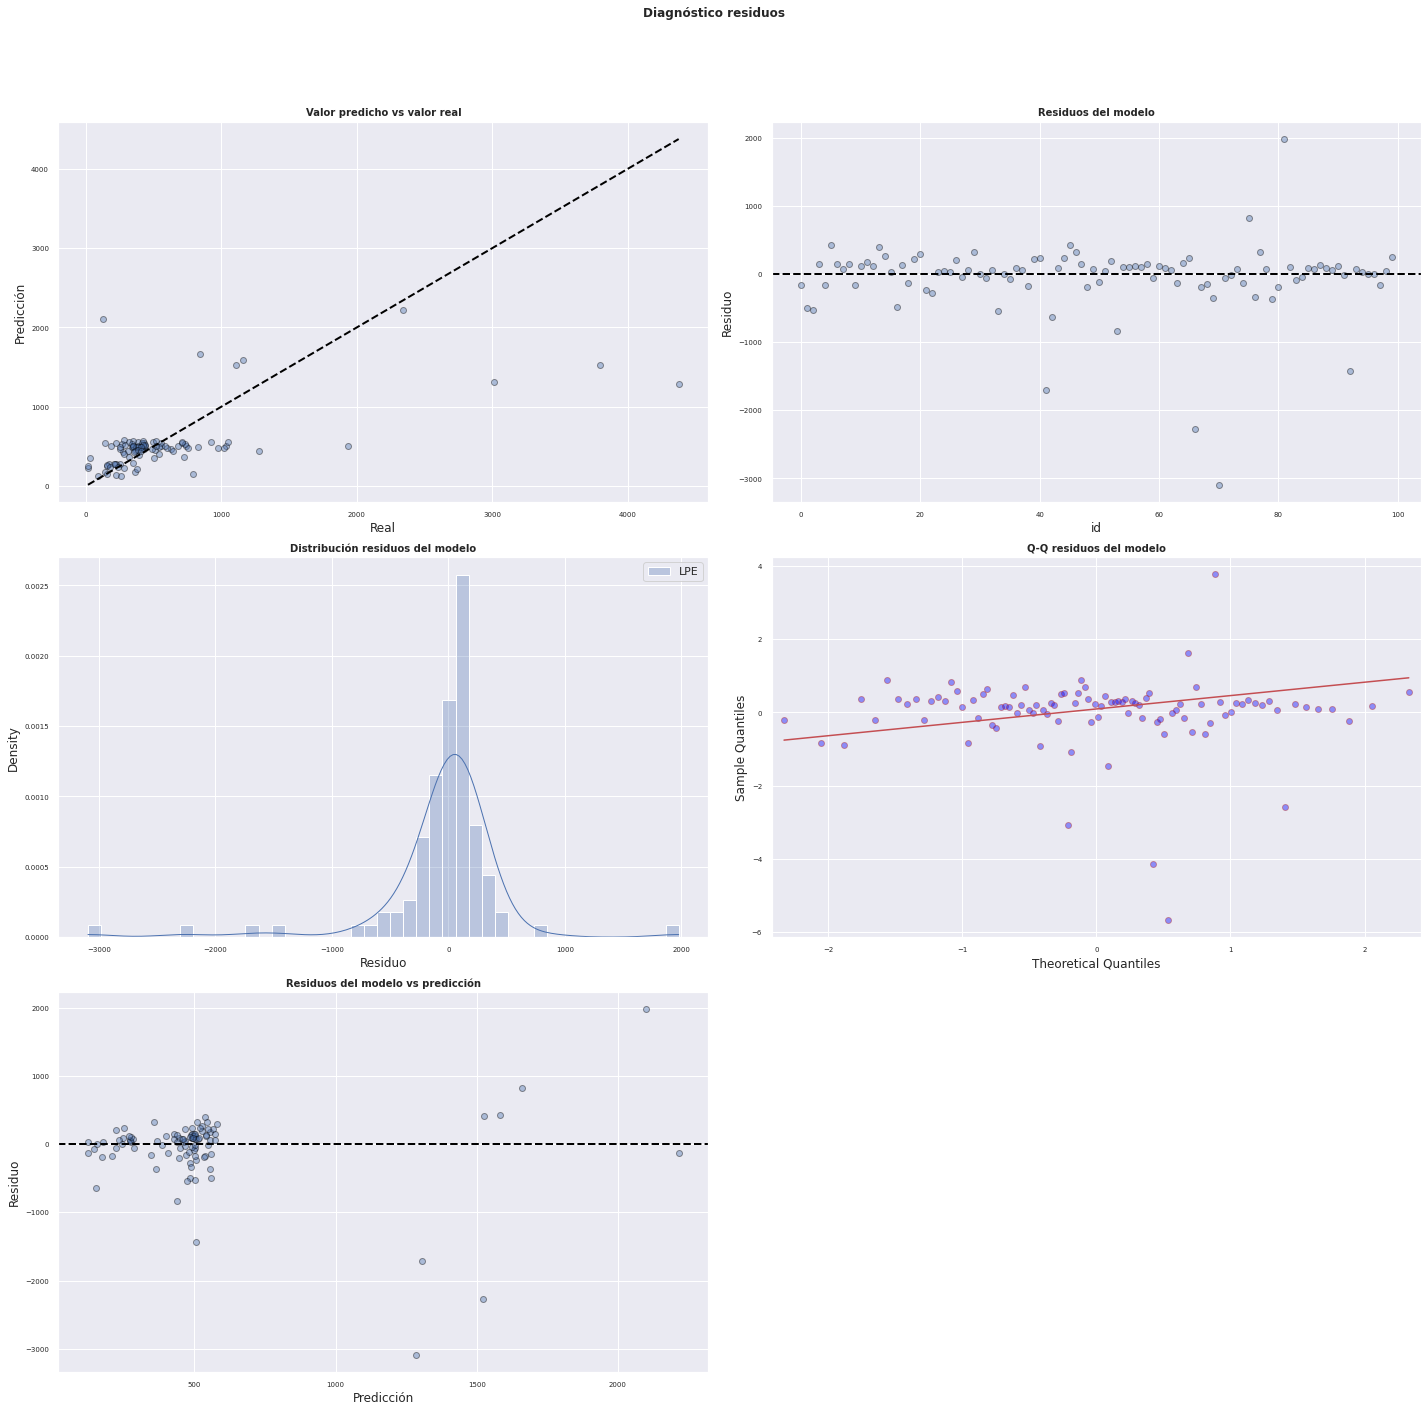

In [93]:
#Analisis de rendimiento del modelo RFC
modelo_RFC = RandomForestRegressor(max_depth=grid.best_params_.get('regressor__modelo__max_depth'), 
                            ccp_alpha=grid.best_params_.get('regressor__modelo__ccp_alpha'), 
                            n_estimators=grid.best_params_.get('regressor__modelo__n_estimators'),
                            min_samples_split=grid.best_params_.get('regressor__modelo__min_samples_split'))  

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_RFC)])
modelo_RFC_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,    
                                    inverse_func=y_inverseTransform    
                                    ) 
modelo_RFC_C.fit(X_train, y_train) 
y_test_hat = modelo_RFC_C.predict(X_test)

residuos_train   = y_test_hat - y_test
print(y_test.max())
print(y_test_hat.max())
print(residuos_train.max())


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))

axes[0, 0].scatter(y_test, y_test_hat, edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'k--', color = 'black', lw=2)
axes[0, 0].set_title('Valor predicho vs valor real', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Predicción')
axes[0, 0].tick_params(labelsize = 7)

axes[0, 1].scatter(list(range(len(y_test))), residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 1].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[0, 1].set_title('Residuos del modelo', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].tick_params(labelsize = 7)

sns.histplot(
    data    = residuos_train,
    stat    = "density",
    kde     = True,
    line_kws= {'linewidth': 1},
    color   = "firebrick",
    alpha   = 0.3,
    ax      = axes[1, 0]
)

axes[1, 0].set_title('Distribución residuos del modelo', fontsize = 10,
                     fontweight = "bold")
axes[1, 0].set_xlabel("Residuo")
axes[1, 0].tick_params(labelsize = 7)


sm.qqplot(
    residuos_train,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    color = 'firebrick',
    alpha = 0.4,
    lw    = 2
)
axes[1, 1].set_title('Q-Q residuos del modelo', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

axes[2, 0].scatter(y_test_hat, residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[2, 0].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[2, 0].set_title('Residuos del modelo vs predicción', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Predicción')
axes[2, 0].set_ylabel('Residuo')
axes[2, 0].tick_params(labelsize = 7)

# Se eliminan los axes vacíos
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Diagnóstico residuos', fontsize = 12, fontweight = "bold");

#**Ejercicio-11.**

11. Repite el ejercicio 8 y 9 para el modelo de regresión lineal múltiple para buscar sus mejores hiperparámetros (realiza la búsqueda con aquellos hiperparámetros que consideres más adecuados) y usando el conjunto de Prueba. Y realiza igualmente el análisis de importancia de factores con este modelo con un diagrama de barras. 


In [94]:
modeloLR = LinearRegression()


pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modeloLR)])
modelo = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,     
                                    inverse_func=y_inverseTransform    
                                    )
dicc_grid = [{'regressor__modelo__fit_intercept':[True, False],
               'regressor__modelo__n_jobs':[1, 3,5]}]

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=7)

grid = GridSearchCV(estimator=modelo, 
                    param_grid=dicc_grid, 
                    cv=cv, 
                    scoring=Me_MAPE)

grid.fit(X_train, np.ravel(y_train))


print('Mejor valor de MAPE obtenido con la mejor combinación:', grid.best_score_)
print('Mejor combinación de valores encontrados de los hiperparámetros:', grid.best_params_)
print('Métrica utilizada:', grid.scoring)

Mejor valor de MAPE obtenido con la mejor combinación: -0.7854908356804486
Mejor combinación de valores encontrados de los hiperparámetros: {'regressor__modelo__fit_intercept': False, 'regressor__modelo__n_jobs': 1}
Métrica utilizada: make_scorer(mi_MAPE, greater_is_better=False)


Feature: 0, Score: 0.03668
Feature: 1, Score: 0.26668
Feature: 2, Score: 0.07902
Feature: 3, Score: 0.51659
Feature: 4, Score: 0.01662
Feature: 5, Score: 0.00270
Feature: 6, Score: -0.00427


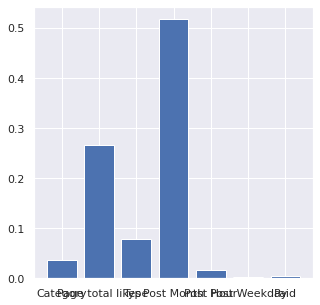

In [111]:
#Modelo evaluado con valores de entrenamiento
modelo_LR = LinearRegression(fit_intercept=grid.best_params_.get('regressor__modelo__fit_intercept'), 
                                  n_jobs=grid.best_params_.get('regressor__modelo__n_jobs')) 

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_LR)])
modelo_LR_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,     
                                    inverse_func=y_inverseTransform    
                                    ) 

modelo_LR_C.fit(X_train, np.ravel(y_train))

importanceLR = permutation_importance(modelo_LR_C, X_train, y_train, n_repeats=10,scoring=Me_MAPE)


for i,v in enumerate(importanceLR['importances_mean']):
	print('Feature: %0d, Score: %.5f' % (i,v))
 
plt.bar(X.columns, abs(importanceLR['importances_mean']))
plt.show()

Feature: 0, Score: 0.11645
Feature: 1, Score: 0.19871
Feature: 2, Score: 0.40175
Feature: 3, Score: 0.13716
Feature: 4, Score: 0.18183
Feature: 5, Score: 0.09396
Feature: 6, Score: 0.00149


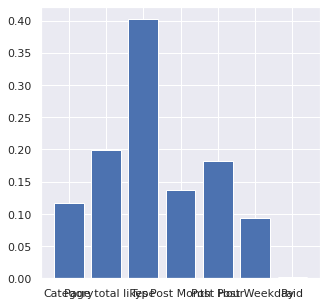

In [112]:
#Modelo evaluado con valores de Prueba
modelo_LR = LinearRegression(fit_intercept=grid.best_params_.get('regressor__modelo__fit_intercept'), 
                                  n_jobs=grid.best_params_.get('regressor__modelo__n_jobs')) 

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_LR)])
modelo_LR_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,     
                                    inverse_func=y_inverseTransform    
                                    ) 

modelo_LR_C.fit(X_test, np.ravel(y_test))

importanceLR = permutation_importance(modelo_LR_C, X_test, y_test, n_repeats=10,scoring=Me_MAPE)


for i,v in enumerate(importanceLR['importances_mean']):
	print('Feature: %0d, Score: %.5f' % (i,v))
 
plt.bar(X.columns, abs(importanceLR['importances_mean']))
plt.show()

LPE    4376
dtype: int64
1953.9319449027714
LPE    1805.388948
dtype: float64


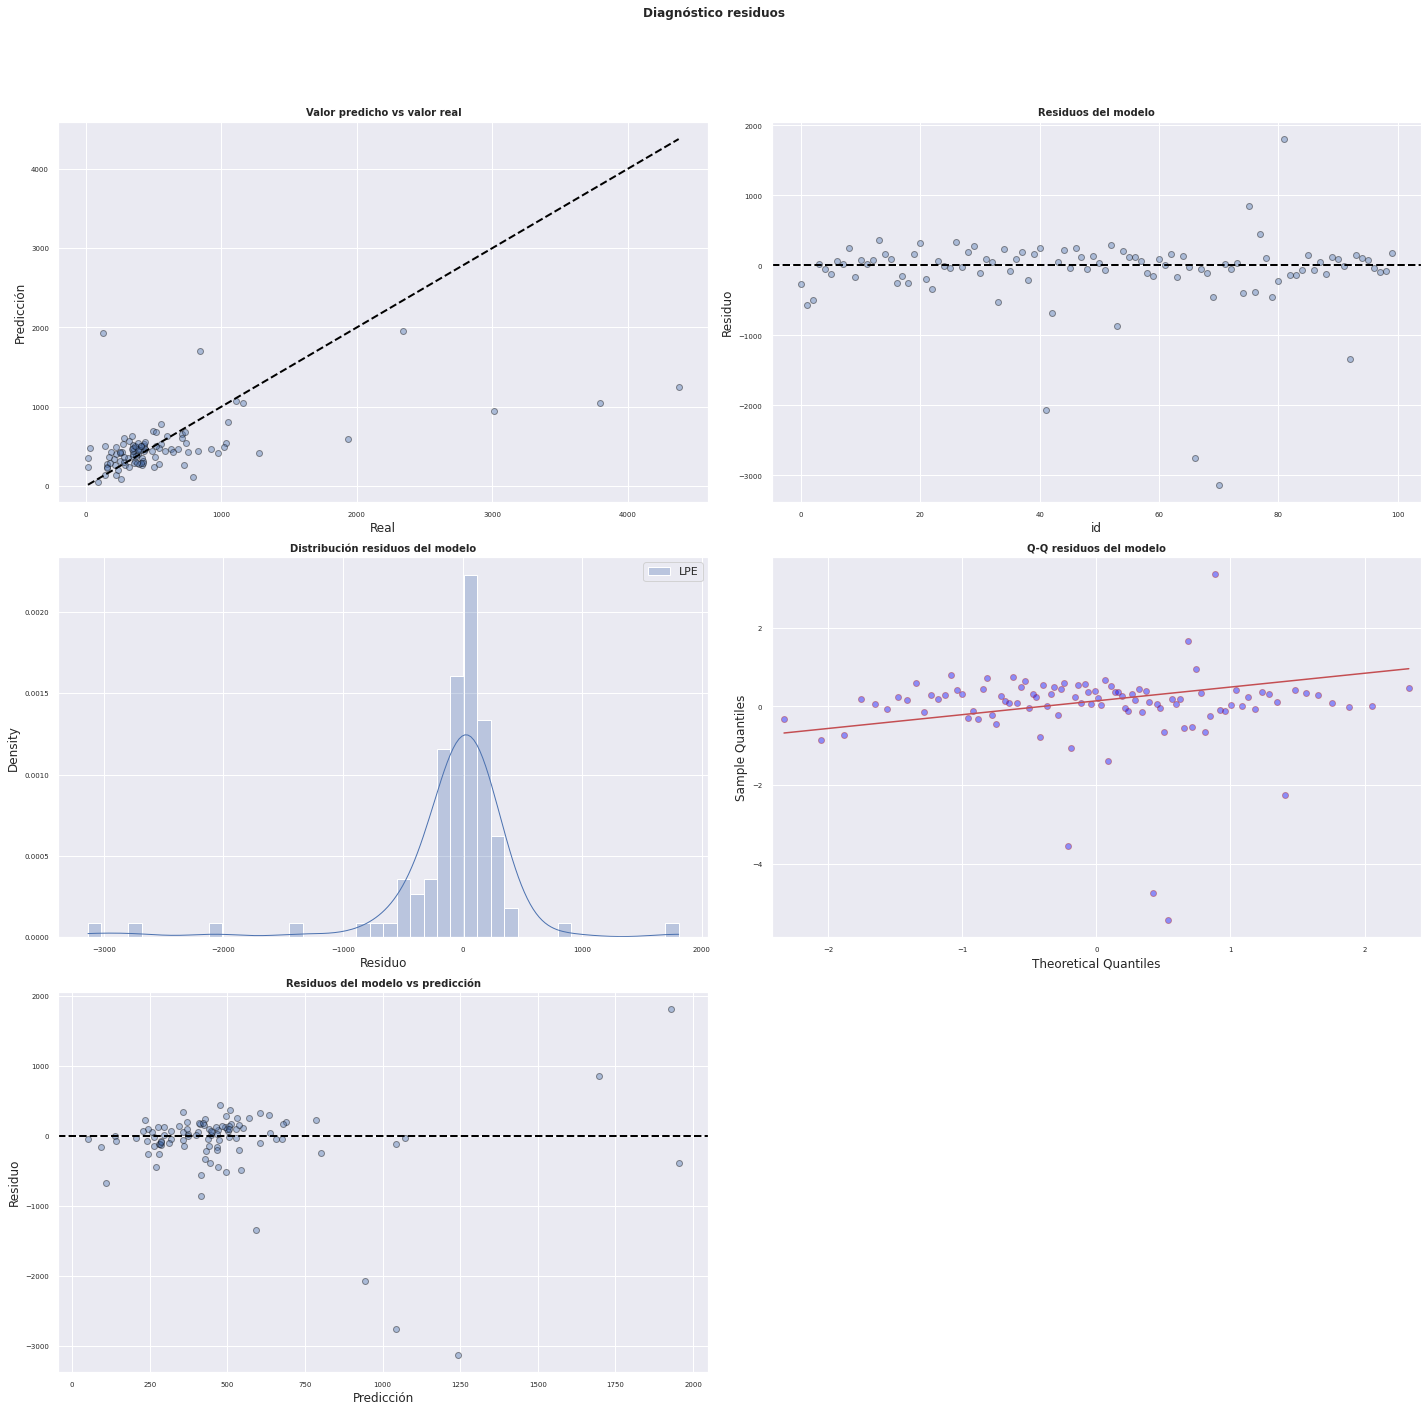

In [97]:
#Analisis de rendimiento del modelo LR
modelo_LR = LinearRegression(fit_intercept=grid.best_params_.get('regressor__modelo__fit_intercept'), 
                                  n_jobs=grid.best_params_.get('regressor__modelo__n_jobs'))   

pipeline = Pipeline(steps=[('ct1',columnasTransformer),('modelo',modelo_LR)])
modelo_LR_C = TransformedTargetRegressor(regressor=pipeline, 
                                    func= y_Transform,    
                                    inverse_func=y_inverseTransform    
                                    ) 
modelo_LR_C.fit(X_train, y_train) 
y_test_hat = modelo_LR_C.predict(X_test)

residuos_train   = y_test_hat - y_test
print(y_test.max())
print(y_test_hat.max())
print(residuos_train.max())


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))

axes[0, 0].scatter(y_test, y_test_hat, edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'k--', color = 'black', lw=2)
axes[0, 0].set_title('Valor predicho vs valor real', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Predicción')
axes[0, 0].tick_params(labelsize = 7)

axes[0, 1].scatter(list(range(len(y_test))), residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 1].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[0, 1].set_title('Residuos del modelo', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].tick_params(labelsize = 7)

sns.histplot(
    data    = residuos_train,
    stat    = "density",
    kde     = True,
    line_kws= {'linewidth': 1},
    color   = "firebrick",
    alpha   = 0.3,
    ax      = axes[1, 0]
)

axes[1, 0].set_title('Distribución residuos del modelo', fontsize = 10,
                     fontweight = "bold")
axes[1, 0].set_xlabel("Residuo")
axes[1, 0].tick_params(labelsize = 7)


sm.qqplot(
    residuos_train,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    color = 'firebrick',
    alpha = 0.4,
    lw    = 2
)
axes[1, 1].set_title('Q-Q residuos del modelo', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

axes[2, 0].scatter(y_test_hat, residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[2, 0].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[2, 0].set_title('Residuos del modelo vs predicción', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Predicción')
axes[2, 0].set_ylabel('Residuo')
axes[2, 0].tick_params(labelsize = 7)

# Se eliminan los axes vacíos
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Diagnóstico residuos', fontsize = 12, fontweight = "bold");

#**Ejercicio-12.**

12. Compara tus resultados con los obtenidos por los autores del artículo de Moro-Rita-Vala con respecto a MAPE. Incluye tus conclusiones finales de la actividad. 

# Conclusiones

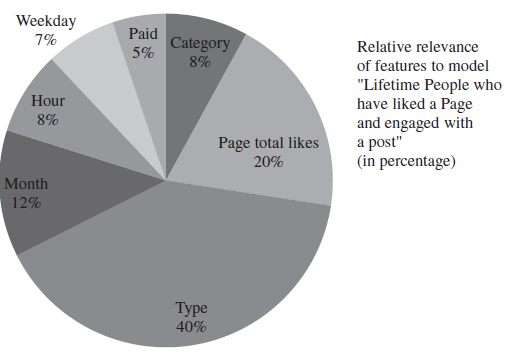

Para concluir, en comparación al modelo del articulo pudimos observar que sus resultado de MAPE del 27% es bastante alentador en sus resultados y difícil equiparar en nuestros modelos. Pero también revisando a profundidad el articulo observamos la diferencia entre los datos y modelos usados. El ejemplo mas claro es que ellos removieron 300 datos del dataset por motivos de confidencialidad y usaron un modelo SVM que probablemente sea el que mejor ejecuta este tipo de problema de manejo de datos de redes sociales. además, que revisando nuestros gráficos de residuos podemos ver que los modelos ejecutan bastante bien. Otra cosa donde diferimos es el feature importance que donde la importancia de la característica (variable) indica cuánto contribuye cada característica a la predicción del modelo. Básicamente, determina el grado de utilidad de una variable específica para un modelo y predicción actual. Por ejemplo, si queremos predecir el peso de una persona en función de la altura, la edad y el nombre, es obvio que la variable altura tendrá la mayor influencia, mientras que el nombre de la variable ni siquiera es relevante para el pes entre ellos, cada modelo asignara una importancia distinta a cada variable y es por ellos que podemos ver dichas diferencias.

###**Fin de la Actividad de la semana 7.**

Referencias
- Bahl, A. (22 de 11 de 2019). MAPE v/s MAE% v/s RMSE. Obtenido de https://agrimabahl.medium.com/mape-v-s-mae-v-s-rmse-3e358fd58f65
- Gad, A. (27 de 07 de 2018). Beginners Ask “How Many Hidden Layers/Neurons to Use in Artificial Neural Networks?”. Obtenido de https://towardsdatascience.com/beginners-ask-how-many-hidden-layers-neurons-to-use-in-artificial-neural-networks-51466afa0d3e
- IBM. (13 de 09 de 2022). Tipos de variables. Obtenido de https://www.ibm.com/docs/es/spss-statistics/saas?topic=charts-variable-types
- Morales, L. E. (2022). Perceptrón Multi Capa (MLP): Interpretación Geométrica (ejemplo). Guadalajara, Mexico: ITESM.
- Morales, L. E. (2022). Redes Neuronales Artificiales: Perceptrón Simple. Guadalajara, Mexico: ITESM.
- Morales, L. E. (2022). Redes Neuronales y Aprendizaje Automático. Guadalajara: ITESM.
- scikit-learn. (29 de 10 de 2022). Varying regularization in Multi-layer Perceptron. Obtenido de https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html#:~:text=Alpha%20is%20a%20parameter%20for,that%20appears%20with%20lesser%20curvatures
- Sérgio Moro, P. R. (2015). Predicting social media performance metrics and evaluation of the impact on brand building: A data mining approach. ELSEVIER, 11.
- Shin, T. (26 de 02 de 2022). Understanding Feature Importance and How to Implement it in Python. Obtenido de https://towardsdatascience.com/understanding-feature-importance-and-how-to-implement-it-in-python-ff0287b20285
- Vandeput, N. (05 de 07 de 2019). Forecast KPIs: RMSE, MAE, MAPE & Bias. Obtenido de https://towardsdatascience.com/forecast-kpi-rmse-mae-mape-bias-cdc5703d242d
- Zvornicanin, E. (01 de 10 de 2022). What is Feature Importance in Machine Learning? Obtenido de https://www.baeldung.com/cs/ml-feature-importance#:~:text=3.-,3.,a%20current%20model%20and%20prediction.


